In [1]:
import gym
import numpy as np
import matplotlib.pyplot as plt

env = gym.make("Taxi-v3")

Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.
/usr/local/lib/python3.12/dist-packages/gym/core.py:317: DeprecationWarning: WARN: Initializing wrapper in old step API which returns one bool instead of two. It is recommended to set `new_step_api=True` to use new step API. This will be the default behaviour in future.
  deprecation(
/usr/local/lib/python3.12/dist-packages/gym/wrappers/step_api_compatibility.py:39: DeprecationWarning: WARN: Initializing environment in old step API which returns one bool instead of two. It is recommended to set `new_step_api=True` to use new step API. This will be the default behaviour in future.
  deprecation(
/usr/local/lib/python3.12/dist-pack

Обучение завершено


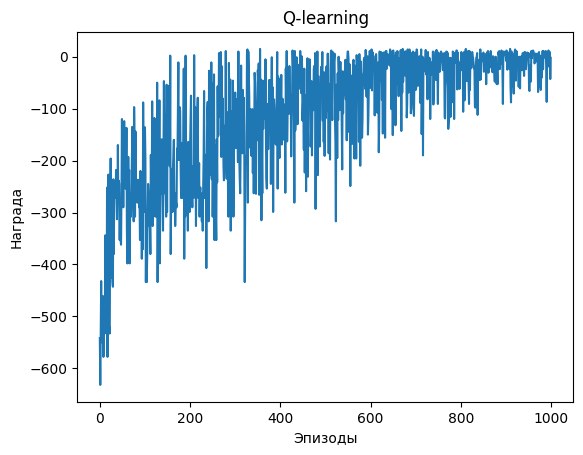

In [10]:
# Гиперпараметры обучения (общие для всех алгоритмов)
alpha = 0.1      # Скорость обучения (learning rate): насколько быстро обновляется Q-таблица (0-1)
gamma = 0.99     # Коэффициент дисконтирования: важность будущих наград (0-1, близко к 1 = дальновидность)
epsilon = 0.1    # Вероятность случайного действия (exploration rate): баланс исследование/эксплуатация
episodes = 1000  # Количество эпизодов обучения

# Инициализация Q-таблицы: строки = состояния (500), столбцы = действия (6)
Q = np.zeros((env.observation_space.n, env.action_space.n))


# выбор действия (ε-жадная стратегия)
def choose_action(state):
    if np.random.rand() < epsilon:
        return env.action_space.sample()  # случайное действие
    else:
        return np.argmax(Q[state])        # лучшее действие

# обучение
rewards = []  # Список для хранения суммарных наград по эпизодам

for episode in range(episodes):  # Цикл по эпизодам
    state = env.reset()  # Начальное состояние (для старого Gym без [0])
    done = False
    total_reward = 0

    while not done:  # Цикл внутри эпизода до завершения
        action = choose_action(state)

        # Выполнение действия (next_state, reward, done, info для старого Gym API)
        next_state, reward, done, info = env.step(action)

        # Ключевая формула Q-learning (off-policy: использует max по всем действиям)
        Q[state, action] += alpha * (
            reward + gamma * np.max(Q[next_state]) - Q[state, action]
        )  # target = reward + gamma * max(Q(next_state))

        state = next_state
        total_reward += reward

    rewards.append(total_reward)

print("Обучение завершено")

# Визуализация сходимости
plt.plot(rewards)
plt.title("Q-learning")
plt.xlabel("Эпизоды")
plt.ylabel("Награда")
plt.show()


SARSA завершено


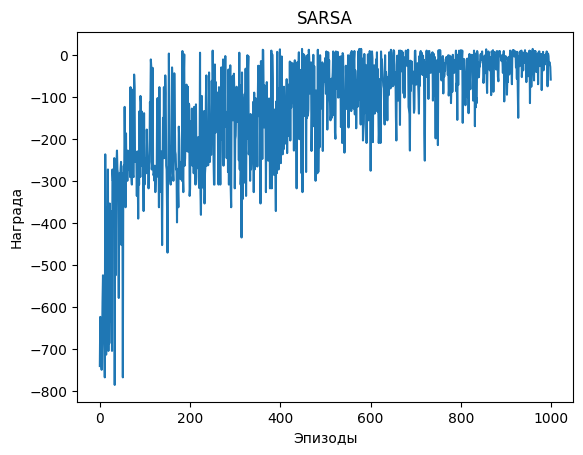

In [13]:
Q = np.zeros((env.observation_space.n, env.action_space.n))  # Новая Q-таблица
rewards_sarsa = []

for episode in range(episodes):
    state = env.reset()
    action = choose_action(state)  # Выбираем действие в текущем состоянии
    done = False
    total_reward = 0

    while not done:
        next_state, reward, done, info = env.step(action)
        next_action = choose_action(next_state)  # Выбираем следующее действие (on-policy!)

        # Формула SARSA: использует реальное следующее действие, а не max
        Q[state, action] += alpha * (
            reward + gamma * Q[next_state, next_action] - Q[state, action]
        )

        state = next_state
        action = next_action  # Обновляем текущее действие
        total_reward += reward

    rewards_sarsa.append(total_reward)

print("SARSA завершено")

plt.plot(rewards_sarsa)
plt.title("SARSA")
plt.xlabel("Эпизоды")
plt.ylabel("Награда")
plt.show()


Double Q-learning завершено


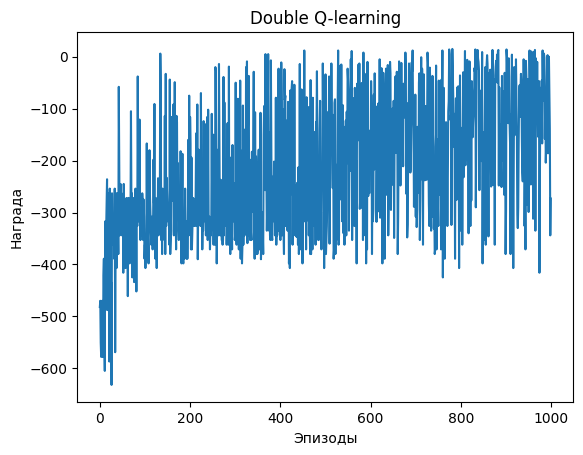

In [15]:
Q1 = np.zeros((env.observation_space.n, env.action_space.n))  # Первая Q-таблица
Q2 = np.zeros((env.observation_space.n, env.action_space.n))  # Вторая Q-таблица

rewards_double = []

for episode in range(episodes):
    state = env.reset()
    done = False
    total_reward = 0

    while not done:
        # Выбор действия: сумма двух таблиц
        if np.random.rand() < epsilon:
            action = env.action_space.sample()
        else:
            action = np.argmax(Q1[state] + Q2[state])

        next_state, reward, done, info = env.step(action)

        # Случайно выбираем таблицу для обновления (50/50)
        if np.random.rand() < 0.5:
            best_action = np.argmax(Q1[next_state])
            # Обновляем Q1, используя Q2 для оценки следующего состояния
            Q1[state, action] += alpha * (
                reward + gamma * Q2[next_state, best_action] - Q1[state, action]
            )
        else:
            best_action = np.argmax(Q2[next_state])
            # Обновляем Q2, используя Q1 для оценки
            Q2[state, action] += alpha * (
                reward + gamma * Q1[next_state, best_action] - Q2[state, action]
            )

        state = next_state
        total_reward += reward

    rewards_double.append(total_reward)

print("Double Q-learning завершено")

plt.plot(rewards_double)
plt.title("Double Q-learning")
plt.xlabel("Эпизоды")
plt.ylabel("Награда")
plt.show()


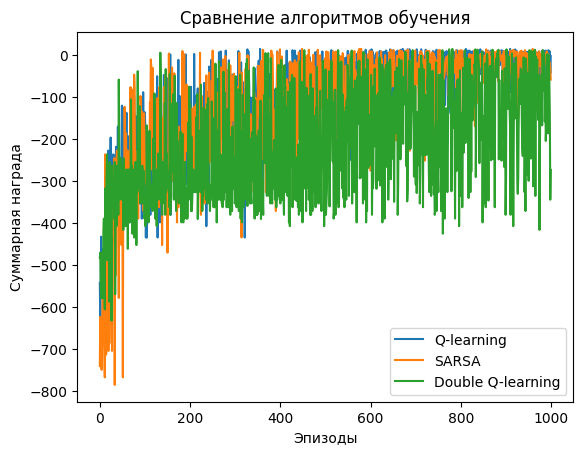

In [16]:
# Сравнение эффективности алгоритмов

plt.plot(rewards, label="Q-learning")
plt.plot(rewards_sarsa, label="SARSA")
plt.plot(rewards_double, label="Double Q-learning")

plt.legend()

plt.title("Сравнение алгоритмов обучения")
plt.xlabel("Эпизоды")
plt.ylabel("Суммарная награда")

plt.show()